# Imports

In [2]:
# Cell 1 — Imports
import os
import sys
sys.path.append("../src")

# Suppress warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import LABEL_MAP, DATA_DIR

print("Imports OK")

Imports OK


# Loading Data

In [3]:
# Disable symlinks warning on Windows
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Optional: add your HF token if you have one
# os.environ["HF_TOKEN"] = "your_token_here"

In [4]:
# Cell 2 — Load AG News
dataset = load_dataset("ag_news")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [5]:
# Explore one sample
sample = dataset["train"][0]
print("Text  :", sample["text"])
print("Label :", sample["label"])
print("Category:", LABEL_MAP[sample["label"]])

Text  : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label : 2
Category: Business


# Cell 3 — Class Distribution Analysis

In [6]:
# Cell 3 — Class Distribution Analysis
import pandas as pd

# Convert training split to pandas dataframe
train_df = pd.DataFrame(dataset["train"])

# Map numeric labels to category names
train_df["category"] = train_df["label"].map(LABEL_MAP)

# Count samples per class
class_counts = train_df["category"].value_counts()
print("Class Distribution:")
print(class_counts)
print("\nPercentage:")
print(round(class_counts / len(train_df) * 100, 2))

Class Distribution:
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Percentage:
category
Business    25.0
Sci/Tech    25.0
Sports      25.0
World       25.0
Name: count, dtype: float64


# # Cell 4 — Visualize Class Distribution

C:\Users\aadil\AppData\Local\Temp\ipykernel_43528\4000954227.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


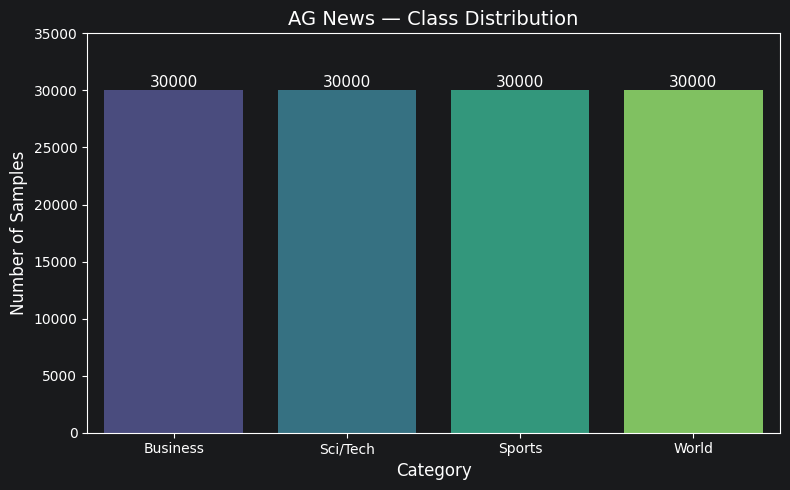

Plot saved.


In [7]:
# Cell 4 — Visualize Class Distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="viridis"
)

plt.title("AG News — Class Distribution", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.ylim(0, 35000)

# Add count labels on top of each bar
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 300, str(count),
             ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("../data/class_distribution.png", dpi=150)
plt.show()

print("Plot saved.")

# Cell 5 — Text Length Distribution

In [8]:
# Cell 5 — Text Length Distribution
# We measure length in words first, then tokens
# This tells us if MAX_LENGTH = 128 is the right choice

train_df["text_length"] = train_df["text"].apply(
    lambda x: len(x.split())
)

print("Text Length Statistics (in words):")
print(train_df["text_length"].describe())

Text Length Statistics (in words):
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


# Cell 6 — Visualize Text Length


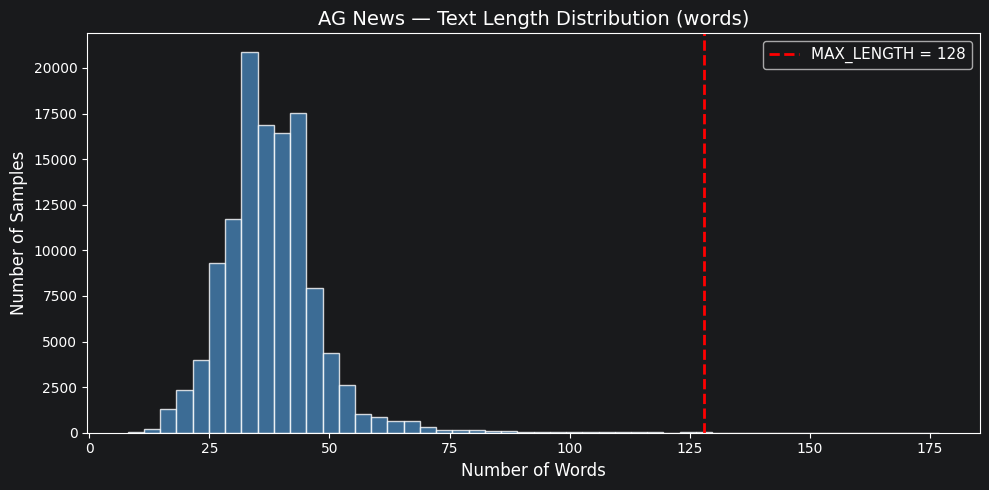

Samples under 128 words: 119962 (99.97%)


In [9]:
# Cell 6 — Text Length Distribution Plot
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["text_length"],
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

# Mark our MAX_LENGTH choice
plt.axvline(
    x=128,
    color="red",
    linestyle="--",
    linewidth=2,
    label="MAX_LENGTH = 128"
)

plt.title("AG News — Text Length Distribution (words)", fontsize=14)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../data/text_length_distribution.png", dpi=150)
plt.show()

# What percentage of samples are under 128 words?
under_128 = (train_df["text_length"] <= 128).sum()
pct = round(under_128 / len(train_df) * 100, 2)
print(f"Samples under 128 words: {under_128} ({pct}%)")

# Cell 7 — Sample Inspection

In [10]:
# Cell 7 — Sample Inspection
# Read real examples to understand what the text looks like
# This helps us understand what BERT will be learning

print("=" * 60)
for label_id, label_name in LABEL_MAP.items():
    # Get 2 samples from each class
    samples = train_df[train_df["label"] == label_id].head(2)

    print(f"\n Category: {label_name} (label={label_id})")
    print("-" * 60)

    for i, row in samples.iterrows():
        print(f" Sample {i}:")
        print(f" Text  : {row['text'][:200]}")
        print(f" Words : {row['text_length']}")
        print()

    print("=" * 60)


 Category: World (label=0)
------------------------------------------------------------
 Sample 492:
 Text  : Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing P
 Words : 46

 Sample 493:
 Text  : S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reve
 Words : 38


 Category: Sports (label=1)
------------------------------------------------------------
 Sample 448:
 Text  : Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American tea
 Words : 64

 Sample 449:
 Text  : Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in f